# AK70 OLG Model with Idiosyncratic Income Uncertainty

To run this code you must store the file survival_probs.xlsx in the working directory

In [2]:
import numpy as np
import pandas as pd
import quantecon as qe
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy import interpolate
import time

try:
    from numba import njit
    _NUMBA = True
    print('numba available — JIT compilation active')
except ImportError:
    _NUMBA = False
    def njit(*args, **kwargs):
        def dec(f): return f
        return dec
    print('numba not found — pure-Python fallback (slower)')

kind_tol = 'linear'

def interp_fn(xp, fp, x, kind=kind_tol):
    if kind == 'linear':
        return np.interp(x, xp, fp)
    f = interpolate.interp1d(xp, fp, kind='cubic',
                             bounds_error=False,
                             fill_value=(fp[0], fp[-1]))
    return f(x)

numba available — JIT compilation active


In [ ]:
import pandas as pd

url = "https://github.com/alerus-econ/dSEA-PhD-Lecture-OLG-2026/Codes/survival_probs.xlsx"
df = pd.read_excel(url)
print(df.head())

## Step 1: Parameterize the model and choose grids

Numerical grids:

- $n_a = 501$ points for the **policy function** asset grid $\mathcal A$;
- $n_{ag} = 1{,}000$ points for the **distribution** asset grid (denser, to reduce mass-allocation error in Step 5).

See slides "Step 1: grids and initial guess".

The convergence tolerance, damping, and outer-loop counter are set here once and reused below.

t_start = time.time()  # total notebook timer

In [4]:
# ----- Asset grids -----
kmin   = 0.0           # borrowing constraint: a >= 0
kmax   = 20.0          # upper bound on the asset grid (must dominate equilibrium support)
na     = 501           # # grid points for policy functions
a      = np.linspace(kmin, kmax, na)

nag    = 2 * na        # denser grid for the distribution (n_ag = 1000 in the slides)
ag     = np.linspace(kmin, kmax, nag)

# ----- Earnings/income grids (used to compute Gini-style statistics) -----
nearn  = 500
emax   = 0.01 * (nearn - 1)
earn   = np.linspace(0, emax, nearn)
income = np.linspace(0, emax, nearn)

# ----- Numerical settings -----
labormax = 0.6      # ceiling on labor supply (corner-solution guard)
eps      = 0.05     # offset to detect boundary optima at a=0 and a=kmax
phi      = 0.80     # damping factor in the OUTER fixed-point loop (Step 7)
tol      = 1e-4     # tolerance for outer-loop convergence
tol1     = 1e-5     # tolerance for golden-section search inside VFI
neg      = -1e10    # sentinel value for utility when c <= 0
nq       = 30       # max # of outer iterations (not used in single-pass version)


### Step 1.1: Demographic data

`survival_probs.xlsx` ships two columns:

- `sp1`: conditional one-year survival probabilities $\phi^s$, $s = 1, \dots, 70$;
- `ef`: age-efficiency profile $\bar y^s$, $s = 1, \dots, 45$ (working ages only), calibrated
  from Hansen (1993).

We expect this file in the working directory. If you keep it in a `data/` subfolder, adjust
the path accordingly.

In [6]:
# Read the survival/efficiency data.
# (The file uses the Heer-Maussner column names sp1 and ef.)
df = pd.read_excel('survival_probs.xlsx')
print(df.head())

arr = df.to_numpy()
sp1 = arr[:, 0]         # phi^s for s=1..70
ef  = arr[0:45, 1]      # bar{y}^s for working ages s=1..45


        sp1        ef
0  0.999197  0.596473
1  0.999170  0.635909
2  0.999142  0.675345
3  0.999114  0.714781
4  0.999085  0.753513


### Step 1.2: Parameter calibration

These match the calibration table in the slides (Section 5).
$\beta = 1.011 > 1$ is admissible because the *effective* discount factor
$\beta\,(1+g_A)^{\gamma(1-\eta)}\,\phi^s$ is well below one once mortality and growth are netted out.

In [8]:
# ----- Demographics -----
nage       = 70                # max age (model ages 1..70 = real-life 21..90)
nw         = 45                # working-age periods (T^W in slides)
Rage       = 46                # first retirement period
nr         = nage - Rage + 1   # 25 retirement periods (T^R)
popgrowth0 = 0.00754           # population growth rate n

# ----- Preferences (KPR-CRRA-with-leisure) -----
beta1 = 1.011                  # discount factor (>1, see note above)
gamma = 0.33                   # consumption weight in u(c, 1-l)
lbar  = 0.25                   # steady-state labor (used only for diagnostics)
eta   = 2.0                    # 1/IES

# ----- Production / firm side -----
ygrowth = 1.02                 # 1 + g_A
alpha   = 0.35                 # capital share
delta   = 0.083                # depreciation rate
rbbar   = 1.04                 # initial guess for gross bond return (diagnostic)

# ----- Fiscal & social security -----
taulbar           = 0.28       # tau^l + tau^p (see Mendoza-Razin 1994)
tauk              = 0.36
tauc              = 0.05
taup              = 0.124      # initial guess for the PAYG contribution rate
replacement_ratio = 0.352      # gross pension replacement rate (US)
bybar             = 0.63       # B/Y
gybar             = 0.18       # G/Y


### Step 1.3: Cohort shares $\mu^s$

Iterate the recursion from the slides:
$$\mu^{s+1} = \frac{\phi^s}{1+n}\,\mu^s, \qquad \mu^1 = 1,$$
then normalize so $\sum_s \mu^s = 1$. This is the only place $\phi^s$ enters the demographic side; it must
be the same vector used in the household and law-of-motion blocks.

We replace the original `for` loop with `np.cumprod` for clarity (and a marginal speedup).

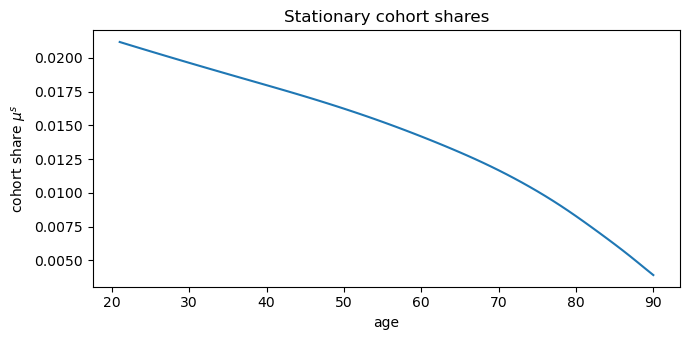

In [10]:
# Vectorized cohort-share recursion.
mass = np.empty(nage)
mass[0]  = 1.0
mass[1:] = np.cumprod(sp1[:nage-1] / (1.0 + popgrowth0))
mass     = mass / mass.sum()        # normalize to one

# Quick visual check
plt.figure(figsize=(7, 3.5))
plt.plot(range(21, 91), mass)
plt.xlabel('age')
plt.ylabel('cohort share $\\mu^s$')
plt.title('Stationary cohort shares')
plt.tight_layout()
plt.show()


### Step 1.4: Productivity process

Idiosyncratic productivity:
$$\epsilon(s,\theta,e) = \theta \cdot e \cdot \bar y^{\,s},$$
with $e \in \{0.57, 1.43\}$ (permanent type, college vs.\ high-school) and $\ln\theta$ following an AR(1):
$$\ln \theta' = \rho \ln\theta + \xi, \qquad \xi \sim \mathcal N(0, \sigma_\xi^2).$$

Tauchen's discretization is implemented in QuantEcon. The current API is
`tauchen(n, rho, sigma, mu=0., n_std=3)`, where `sigma` is the **standard deviation** of the
innovation (not the variance), so we pass `np.sqrt(sigmae)`.

In [12]:
# ----- Permanent productivity types -----
nperm   = 2
perm    = np.array([0.57, 1.43])     # high-school vs college (150% wage premium)

# ----- Stochastic AR(1) productivity -----
lamb0   = 0.96                       # rho (Huggett 1996)
sigmae  = 0.045                      # variance of the innovation xi
sigmay1 = 0.38                       # variance of log earnings of 21-year-olds
ny      = 5                          # number of theta states
m_grid  = 1                          # grid half-width in std deviations
                                     #   (renamed from `m` to avoid clash with VFI loop counter)

# Tauchen wants the *standard deviation* of the innovation
sigma_xi = np.sqrt(sigmae)

# Discretize the AR(1) on a grid of n_std = m_grid unconditional std deviations
mc = qe.markov.approximation.tauchen(n=ny, rho=lamb0, sigma=sigma_xi,
                                     mu=0.0, n_std=m_grid)
ye  = mc.state_values                # log-productivity grid (5 points)
py  = mc.P                           # transition matrix Prob(theta' | theta)
ye1 = np.exp(ye)                     # productivity in levels

# Initial mass distribution of 21-year-olds over theta states.
# sigmay1 here is treated as a VARIANCE (so np.sqrt(sigmay1) gives the std).
muy = np.zeros(ny)
w   = ye[1] - ye[0]
muy[0]    = norm.cdf((ye[0]    + w/2) / np.sqrt(sigmay1))
muy[ny-1] = 1.0 - norm.cdf((ye[ny-1] - w/2) / np.sqrt(sigmay1))
for i in range(1, ny - 1):
    muy[i] = (norm.cdf((ye[i] + w/2) / np.sqrt(sigmay1))
              - norm.cdf((ye[i] - w/2) / np.sqrt(sigmay1)))

print('theta grid (log) :', ye)
print('theta grid (level):', ye1)
print('Initial cohort distribution nu(theta):', muy)
print('Transition matrix Prob(theta\'|theta):')
print(py)


theta grid (log) : [-0.75761441 -0.3788072   0.          0.3788072   0.75761441]
theta grid (level): [0.46878342 0.6846776  1.         1.46054142 2.13318125]
Initial cohort distribution nu(theta): [0.17832698 0.20099834 0.24134936 0.20099834 0.17832698]
Transition matrix Prob(theta'|theta):
[[7.73372648e-01 2.21016440e-01 5.60316133e-03 7.75060470e-06
  5.07152209e-10]
 [1.67451351e-01 6.26847552e-01 2.01136034e-01 4.55946946e-03
  5.59353209e-06]
 [3.69684802e-03 1.82269992e-01 6.28066320e-01 1.82269992e-01
  3.69684802e-03]
 [5.59353209e-06 4.55946946e-03 2.01136034e-01 6.26847552e-01
  1.67451351e-01]
 [5.07152234e-10 7.75060470e-06 5.60316133e-03 2.21016440e-01
  7.73372648e-01]]


### Helper: Gini coefficient

Used to compute Gini coefficients for wages, earnings, income and wealth from the
cross-sectional measure. The function below assumes `x` is already sorted ascending.

In [14]:
def ginid(x, gy, ng):
    """
    Vectorized Gini. x sorted ascending. Uses cumsum — same result as scalar loop.
    """
    x = np.maximum(x, 0.0)
    xmean = np.dot(x, gy)
    if xmean == 0.0:
        return 0.0
    cumF   = np.cumsum(gy * (x / xmean))
    F_prev = np.empty_like(cumF)
    F_prev[0]  = 0.0
    F_prev[1:] = cumF[:-1]
    return 1.0 - np.dot(cumF + F_prev, gy)

### Calibration check wage Gini

Construct the joint distribution of hourly wages $w_t \cdot \epsilon(s,\theta,e)$ across all
working-age agents, and compute its Gini. The slides target a Gini of **0.375** (US data).
The grid half-width $m$ in Tauchen was calibrated to deliver this number.

In [16]:
# Distribution of wages (workers only).
# Last index 0 = wage value, 1 = mass weight.
gwages = np.zeros((nw, nperm, ny, 2))

# Initialization at age s = 1 (real-life 21).
for iperm in range(nperm):
    for iy in range(ny):
        gwages[0, iperm, iy, 0] = ye1[iy] * perm[iperm] * ef[0]
        gwages[0, iperm, iy, 1] = 0.5 * muy[iy] * mass[0] / mass[0:nw].sum()

# Roll forward: cohort shares evolve via mortality + theta transitions.
for i in range(1, nw):
    for iperm in range(nperm):
        for iy in range(ny):
            gwages[i, iperm, iy, 0] = ye1[iy] * perm[iperm] * ef[i]
            for iy1 in range(ny):
                gwages[i, iperm, iy1, 1] += (sp1[i-1] / (1 + popgrowth0)
                                             * py[iy, iy1] * gwages[i-1, iperm, iy, 1])

for iperm in range(nperm):
    for iy in range(ny):
        gwages[nw-1, iperm, iy, 0] = ye1[iy] * perm[iperm] * ef[nw-1]

# Flatten to (wage, mass) pairs, sort by wage, compute Gini.
fwage = np.zeros((nw * nperm * ny, 2))
i0 = 0
for i in range(nw):
    for iperm in range(nperm):
        for iy in range(ny):
            fwage[i0, 0] = gwages[i, iperm, iy, 0]
            fwage[i0, 1] = gwages[i, iperm, iy, 1]
            i0 += 1

y0 = fwage[fwage[:, 0].argsort()]
gini_wages = ginid(y0[:, 0], y0[:, 1], nw * nperm * ny)
print(f'Gini wages (model) = {gini_wages:.4f}    target ~ 0.375')


Gini wages (model) = 0.3738    target ~ 0.375


## Step 2 Initial guesses for the outer loop

We need starting values for $(\widetilde K, \widetilde L, \bar l, \tau^p, \tau^l, \widetilde{Tr})$.
The interior steady-state guess in the slides:
- $\bar l = 0.30$, $\widetilde L = 0.30$ (workforce share $\approx 78\%$)
- $r = 3\%$ $\Rightarrow$ $\widetilde K \approx 1.708$
- $\widetilde \Omega \approx 1.26\,\widetilde K$ (since $B/Y = 0.63$, $K/Y \approx 3$)
- $\widetilde{Tr} = 0.01$

## Step 3 Factor prices and pension benefit

Given $(\widetilde K, \widetilde L)$:
$$w = (1-\alpha)\widetilde K^\alpha \widetilde L^{-\alpha}, \quad
  r = \alpha\widetilde K^{\alpha-1} \widetilde L^{1-\alpha}, \quad
  r^b = (1-\tau^k)(r-\delta).$$

Pension benefit: $\widetilde{pen} = \mathit{repl} \cdot w \cdot \bar l$.

In [18]:
# ----- Factor-price and production functions -----
def wage(k, l):
    return (1 - alpha) * k**alpha * l**(-alpha)

def interest(k, l):
    return alpha * k**(alpha - 1) * l**(1 - alpha)

def production(k, l):
    return k**alpha * l**(1 - alpha)

# ----- Initial guesses -----
rbar       = 0.03
nbar       = 0.30
mean_labor = 0.30
kbar       = (alpha / (rbar + delta))**(1 / (1 - alpha)) * nbar
omega      = kbar * 1.2
trbar      = 0.01
bequests   = 0.0

w  = wage(kbar, nbar)
r  = interest(kbar, nbar)
rb = (1 - tauk) * (r - delta)            # no-arbitrage bond return

# Pension benefit and PAYG balance.
# (Use the *update* formula consistently: pen = repl * w * bar{l}.)
pen   = replacement_ratio * w * mean_labor
taup  = pen * mass[nw:nage].sum() / (w * nbar)
taun  = taulbar - taup

print(f'kbar = {kbar:.4f}')
print(f'w    = {w:.4f}    r = {r:.4f}    rb = {rb:.4f}')
print(f'pen  = {pen:.4f}  tau^p = {taup:.4f}  tau^n = {taun:.4f}')


kbar = 1.7080
w    = 1.1948    r = 0.1130    rb = 0.0192
pen  = 0.1262  tau^p = 0.0773  tau^n = 0.2027


### Helper Golden Section Search

One-dimensional **maximizer** on a bracketing triple $(a_y, b_y, c_y)$. Used inside both the retiree
and the worker VFI to find optimal next-period assets $\tilde a'$.

In [20]:
def GoldenSectionMax(f, ay, by, cy, tol):
    """
    Golden-section search for the maximizer of `f` on the bracketing triple [ay, by, cy].
    Returns the argmax with absolute tolerance `tol` on the bracket size.
    """
    r1 = 0.61803399
    r2 = 1 - r1
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by
        x2 = by + r2 * (cy - by)
    else:
        x2 = by
        x1 = by - r2 * (by - ay)
    f1 = -f(x1)
    f2 = -f(x2)
    while abs(x3 - x0) > tol * (abs(x1) + abs(x2)):
        if f2 < f1:
            x0, x1 = x1, x2
            x2 = r1 * x1 + r2 * x3
            f1 = f2
            f2 = -f(x2)
        else:
            x3, x2 = x2, x1
            x1 = r1 * x2 + r2 * x0
            f2 = f1
            f1 = -f(x1)
    return x1 if f1 <= f2 else x2

# quick sanity check
def _quad(x):
    return -x**2 + 4*x + 6
print('GSS test (should be ~2):', GoldenSectionMax(_quad, -2.2, 0.0, 10.0, tol1))


GSS test (should be ~2): 2.000001074862927


### Numba-compiled VFI helpers

`@njit` compiles bracketing search and golden-section refinement to machine code.
First call triggers JIT compilation (~5 s); subsequent calls run at C speed.
When numba is unavailable the decorator is a no-op and these run as plain Python.

In [22]:
# ── retiree helpers ──────────────────────────────────────────────────────

@njit
def _ret_val(x, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn):
    c = (a0_rb - ygrowth * x) / (1.0 + tauc)
    if c <= 0.0:
        return neg
    if eta == 1.0:
        u = gamma * np.log(c)
    else:
        u = c ** (gamma * (1.0 - eta)) / (1.0 - eta)
    return u + disc * np.interp(x, ag, vn)

@njit
def _gss_ret(ay, by, cy, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, tol, ag, vn):
    R = 0.61803399; r2 = 1.0 - R
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by; x2 = by + r2 * (cy - by)
    else:
        x2 = by; x1 = by - r2 * (by - ay)
    f1 = -_ret_val(x1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    f2 = -_ret_val(x2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    while abs(x3 - x0) > tol * (abs(x1) + abs(x2)):
        if f2 < f1:
            x0 = x1; x1 = x2; x2 = R * x1 + r2 * x3; f1 = f2
            f2 = -_ret_val(x2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
        else:
            x3 = x2; x2 = x1; x1 = R * x2 + r2 * x0; f2 = f1
            f1 = -_ret_val(x1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vn)
    return x1 if f1 <= f2 else x2

@njit
def _vfi_ret_inner(ag, na, vr_next, rb1, pen_tr, ygrowth, tauc,
                   disc, gamma, eta, neg, tol1, eps):
    """One retiree backward-induction step. Returns (aropt, cropt, vr) columns."""
    aropt = np.empty(na); cropt = np.empty(na); vr_out = np.empty(na)
    da = ag[1] - ag[0]
    for ia in range(na):
        a0_rb = rb1 * ag[ia] + pen_tr
        ax, bx, cx = 0.0, -1.0, -2.0; v0 = neg; j = -1
        while ax > bx or bx > cx:
            j += 1
            v1 = _ret_val(ag[j], a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)
            if v1 > v0:
                ax = ag[0] if j == 0 else ag[j - 1]; bx = ag[j]; v0 = v1
            else:
                cx = ag[j]
            if j == na - 1:
                ax = ag[na - 2]; bx = ag[na - 1]; cx = ag[na - 1]
        if ax == bx:
            bx2 = ax + da * eps
            if (_ret_val(ax,  a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next) >
                    _ret_val(bx2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)):
                k1 = ag[0]
            else:
                k1 = _gss_ret(ax, bx2, ag[1], a0_rb, ygrowth, tauc, disc,
                               gamma, eta, neg, tol1, ag, vr_next)
        elif bx == cx:
            bx2 = ag[na - 1] - eps * (ag[na - 1] - ag[na - 2])
            if (_ret_val(ag[na - 1], a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next) >
                    _ret_val(bx2, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)):
                k1 = ag[na - 1]
            else:
                k1 = _gss_ret(ag[na - 2], bx2, ag[na - 1], a0_rb, ygrowth, tauc, disc,
                               gamma, eta, neg, tol1, ag, vr_next)
        else:
            k1 = _gss_ret(ax, bx, cx, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, tol1, ag, vr_next)
        aropt[ia] = k1
        cropt[ia] = (a0_rb - ygrowth * k1) / (1.0 + tauc)
        vr_out[ia] = _ret_val(k1, a0_rb, ygrowth, tauc, disc, gamma, eta, neg, ag, vr_next)
    return aropt, cropt, vr_out


# ── worker helpers ────────────────────────────────────────────────────────

@njit
def _wk_val(x, rb1_a0_tr, denom, ygrowth, tauc, labormax,
            disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age):
    """Worker Bellman RHS at x. vw_T shape (ny, na) with contiguous rows."""
    labor = gamma - (rb1_a0_tr - ygrowth * x) * (1.0 - gamma) / denom
    if labor < 0.0:      labor = 0.0
    if labor > labormax: labor = labormax
    c = (rb1_a0_tr + denom * labor - ygrowth * x) / (1.0 + tauc)
    if c <= 0.0:
        return neg
    if eta == 1.0:
        u = gamma * np.log(c) + (1.0 - gamma) * np.log(1.0 - labor)
    else:
        u = (c ** (gamma * (1.0 - eta)) * (1.0 - labor) ** ((1.0 - gamma) * (1.0 - eta))) / (1.0 - eta)
    if last_age:
        return u + disc * np.interp(x, ag, vr0)
    v_exp = 0.0
    for iy1 in range(ny):
        v_exp += py_row[iy1] * np.interp(x, ag, vw_T[iy1])
    return u + disc * v_exp

@njit
def _gss_wk(ay, by, cy, rb1_a0_tr, denom, ygrowth, tauc, labormax,
            disc, gamma, eta, neg, tol, ag, vr0, vw_T, ny, py_row, last_age):
    R = 0.61803399; r2 = 1.0 - R
    x0, x3 = ay, cy
    if abs(cy - by) <= abs(by - ay):
        x1 = by; x2 = by + r2 * (cy - by)
    else:
        x2 = by; x1 = by - r2 * (by - ay)
    f1 = -_wk_val(x1, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    f2 = -_wk_val(x2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    while abs(x3 - x0) > tol * (abs(x1) + abs(x2)):
        if f2 < f1:
            x0 = x1; x1 = x2; x2 = R * x1 + r2 * x3; f1 = f2
            f2 = -_wk_val(x2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
        else:
            x3 = x2; x2 = x1; x1 = R * x2 + r2 * x0; f2 = f1
            f1 = -_wk_val(x1, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    return x1 if f1 <= f2 else x2

@njit
def _vfi_wk_inner(ag, na, ny, rb1, trbar, w_eff, taun_taup, ygrowth, tauc, labormax,
                  disc, gamma, eta, neg, tol1, eps, py_row, vw_T, vr0, last_age):
    """One (iy, iperm, iage) VFI pass. Returns (awopt, lopt, cwopt, vw) columns."""
    awopt_c = np.empty(na); lopt_c = np.empty(na)
    cwopt_c = np.empty(na); vw_c   = np.empty(na)
    da    = ag[1] - ag[0]
    denom = (1.0 - taun_taup) * w_eff
    j0 = -1
    for ia in range(na):
        rb1_a0_tr = rb1 * ag[ia] + trbar
        ax, bx, cx = 0.0, -1.0, -2.0; v0 = neg; j = j0
        while ax > bx or bx > cx:
            j += 1
            v1 = _wk_val(ag[j], rb1_a0_tr, denom, ygrowth, tauc, labormax,
                         disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
            if v1 > v0:
                j0 = max(-1, j - 2)
                ax = ag[0] if j == 0 else ag[j - 1]; bx = ag[j]; v0 = v1
            else:
                cx = ag[j]
            if j == na - 1:
                ax = ag[na - 2]; bx = ag[na - 1]; cx = ag[na - 1]
        if ax == bx:
            bx2 = ax + da * eps
            if (_wk_val(ax,  rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age) >
                    _wk_val(bx2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)):
                k1 = ag[0]
            else:
                k1 = _gss_wk(ax, bx2, ag[1], rb1_a0_tr, denom, ygrowth, tauc, labormax,
                             disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny, py_row, last_age)
        elif bx == cx:
            bx2 = ag[na - 1] - eps * (ag[na - 1] - ag[na - 2])
            if (_wk_val(ag[na - 1], rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age) >
                    _wk_val(bx2, rb1_a0_tr, denom, ygrowth, tauc, labormax, disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)):
                k1 = ag[na - 1]
            else:
                k1 = _gss_wk(ag[na - 2], bx2, ag[na - 1], rb1_a0_tr, denom, ygrowth, tauc, labormax,
                             disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny, py_row, last_age)
        else:
            k1 = _gss_wk(ax, bx, cx, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                         disc, gamma, eta, neg, tol1, ag, vr0, vw_T, ny, py_row, last_age)
        awopt_c[ia] = k1
        labor = gamma - (rb1_a0_tr - ygrowth * k1) * (1.0 - gamma) / denom
        if labor < 0.0:      labor = 0.0
        if labor > labormax: labor = labormax
        lopt_c[ia]  = labor
        cwopt_c[ia] = (rb1_a0_tr + denom * labor - ygrowth * k1) / (1.0 + tauc)
        vw_c[ia]    = _wk_val(k1, rb1_a0_tr, denom, ygrowth, tauc, labormax,
                              disc, gamma, eta, neg, ag, vr0, vw_T, ny, py_row, last_age)
    return awopt_c, lopt_c, cwopt_c, vw_c

## Step 4 Backward induction (Value Function Iteration)

### 4a Utility function and retiree's problem

Instantaneous utility (KPR form):
$$u(c, 1-l) = \frac{\big(c^\gamma\,(1-l)^{1-\gamma}\big)^{1-\eta}}{1-\eta}.$$

Retiree's stationary Bellman equation ($l = 0$ since retirement is mandatory):
$$V^s(\tilde a) = \max_{\tilde a' \ge 0}\; u(\tilde c, 1) + (1+g_A)^{\gamma(1-\eta)}\beta\,\phi^s\,V^{s+1}(\tilde a').$$

Solved by **backward induction** from $s = T = 70$. At the terminal age, $\tilde a^{T+1} = 0$
and the entire wealth is consumed.

In [24]:
def u(c, l):
    """Stationary instantaneous utility u(c, 1-l) under KPR-CRRA-with-leisure."""
    if eta == 1:
        return gamma * np.log(c) + (1 - gamma) * np.log(1 - l)
    return (c**(gamma*(1-eta)) * (1-l)**((1-gamma)*(1-eta))) / (1 - eta)


# ----- Retiree storage -----
vr     = np.zeros((na, nr))      # value function on (a, retiree-age)
aropt  = np.zeros((na, nr))      # next-period asset policy
cropt  = np.zeros((na, nr))      # consumption policy

# ----- Terminal condition at age T = nage = 70 (retiree-index nr-1) -----
for ia in range(na):
    c = ((1 + (1 - tauk) * (r - delta)) * a[ia] + pen + trbar) / (1 + tauc)
    vr[ia, nr-1]    = u(c, 0)
    cropt[ia, nr-1] = c
    aropt[ia, nr-1] = 0.0


**Backward induction loop for retirees.** At each age and each wealth grid point we:

1. Bracket the maximizer of the Bellman RHS by walking up the `a` grid until the value
   stops increasing (monotonicity of the policy function helps here, but we don't exploit it
   for retirees since the loop is cheap).
2. Refine the bracket with golden-section search.
3. Handle boundary cases at $\tilde a' = 0$ and $\tilde a' = \tilde a^{\max}$ separately.

> **Speed change vs. original:** `vr_polate` is now a closure over `np.interp` rather than a
> freshly constructed `scipy.interpolate.interp1d` object. Same answer, ~50Ã— faster.

Retiree VFI: 10.55 s  (first run includes numba compile)


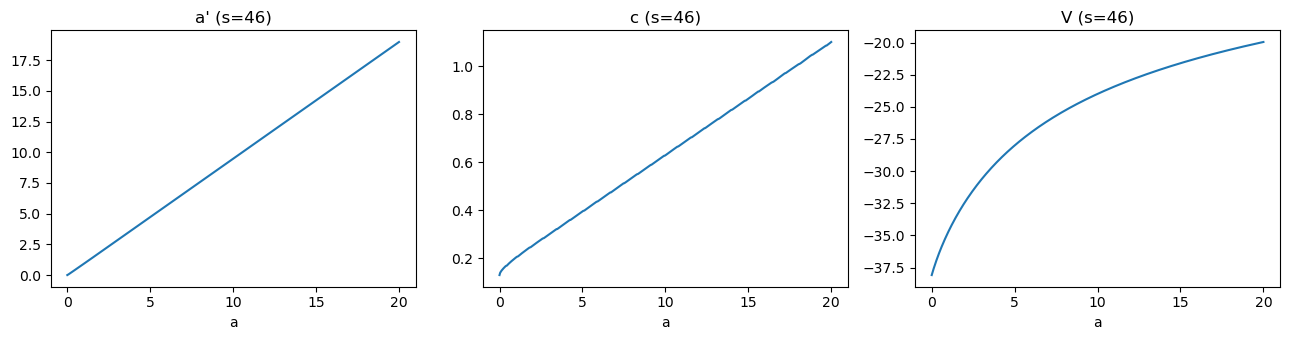

In [26]:
t0 = time.time()

vr    = np.zeros((na, nr))
aropt = np.zeros((na, nr))
cropt = np.zeros((na, nr))

rb1    = 1.0 + (1.0 - tauk) * (r - delta)
pen_tr = pen + trbar      # pension + lump-sum transfer

# Terminal age: all wealth consumed, no next period
for ia in range(na):
    c = (rb1 * a[ia] + pen_tr) / (1 + tauc)
    vr[ia, nr-1]    = u(c, 0)
    cropt[ia, nr-1] = c
    aropt[ia, nr-1] = 0.0

# Backward induction using numba-jitted inner loop per age
for iage in range(nr - 2, -1, -1):
    disc    = ygrowth ** (gamma * (1 - eta)) * sp1[nw + iage] * beta1
    vr_next = np.ascontiguousarray(vr[:, iage + 1])
    aropt_c, cropt_c, vr_c = _vfi_ret_inner(
        a, na, vr_next, rb1, pen_tr, ygrowth, tauc, disc, gamma, eta, neg, tol1, eps)
    aropt[:, iage] = aropt_c
    cropt[:, iage] = cropt_c
    vr[:, iage]    = vr_c

print(f'Retiree VFI: {time.time()-t0:.2f} s  (first run includes numba compile)')

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(a, aropt[:, 0]); axes[0].set_title("a' (s=46)"); axes[0].set_xlabel('a')
axes[1].plot(a, cropt[:, 0]); axes[1].set_title('c (s=46)');  axes[1].set_xlabel('a')
axes[2].plot(a, vr[:, 0]);    axes[2].set_title('V (s=46)');  axes[2].set_xlabel('a')
plt.tight_layout(); plt.show()

### 4b Worker's value function

Worker's stationary Bellman:
$$V^s(\theta, e, \tilde a) = \max_{\tilde a',\, l}
  u(\tilde c, 1-l) + (1+g_A)^{\gamma(1-\eta)}\beta\,\phi^s
   \sum_{\theta'} \mathrm{Prob}(\theta'|\theta)\,V^{s+1}(\theta', e, \tilde a').$$

The intra-temporal FOC for $l$ given $\tilde a'$ has the closed form (slides Step 4):
$$l = \gamma - \frac{1-\gamma}{(1-\tau^l-\tau^p)\,\epsilon(s,\theta,e)\,w}
\bigg[\big(1+(1-\tau^k)(r-\delta)\big)\tilde a + \widetilde{Tr} - (1+g_A)\tilde a'\bigg],$$

so the 2-D problem reduces to a **nested 1-D** golden-section search over $\tilde a'$. We exploit
monotonicity of the policy in $\tilde a$ to start the bracket search from the previous grid point's
optimum (the variable `m0`).

> **Speed change vs. original:** all three interpolations (next-period value, consumption, labor)
> use `np.interp` instead of `scipy.interpolate.interp1d`. The 2-D policy update is still the
> dominant cost but is now ~30â€“50Ã— faster.

In [28]:
vw    = np.zeros((na, ny, nperm, nw))
awopt = np.zeros((na, ny, nperm, nw))
lopt  = np.zeros((na, ny, nperm, nw))
cwopt = np.zeros((na, ny, nperm, nw))

rb1 = 1.0 + (1.0 - tauk) * (r - delta)
vr0 = np.ascontiguousarray(vr[:, 0])   # first retirement-age value column

t0 = time.time()
for iage in range(nw - 1, -1, -1):
    last_age  = (iage == nw - 1)
    disc_base = ygrowth ** (gamma * (1 - eta)) * sp1[iage] * beta1
    for iperm in range(nperm):
        for iy in range(ny):
            w_eff  = w * ef[iage] * perm[iperm] * ye1[iy]
            py_row = np.ascontiguousarray(py[iy])
            if last_age:
                vw_T = np.zeros((ny, na))            # unused for last working age
            else:
                # transpose: each row vw_T[iy1] is a contiguous (na,) array
                vw_T = np.ascontiguousarray(vw[:, :, iperm, iage + 1].T)
            awopt_c, lopt_c, cwopt_c, vw_c = _vfi_wk_inner(
                a, na, ny, rb1, trbar, w_eff, taun + taup, ygrowth, tauc, labormax,
                disc_base, gamma, eta, neg, tol1, eps,
                py_row, vw_T, vr0, last_age)
            awopt[:, iy, iperm, iage] = awopt_c
            lopt[:,  iy, iperm, iage] = lopt_c
            cwopt[:, iy, iperm, iage] = cwopt_c
            vw[:,    iy, iperm, iage] = vw_c

Worker VFI: 23.24 s


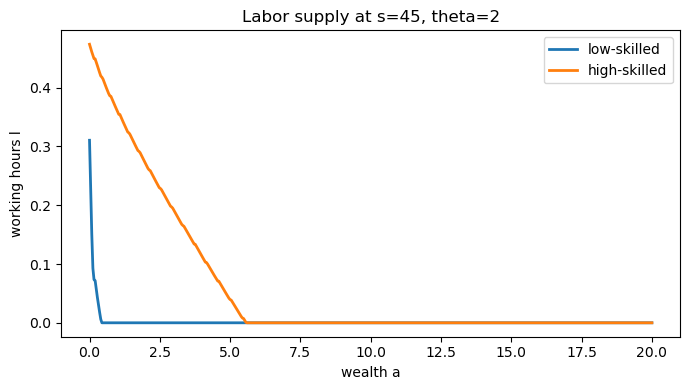

In [29]:
print(f'Worker VFI: {time.time()-t0:.2f} s')

iage0, iy0 = 44, 1
fig, ax_ = plt.subplots(figsize=(7, 4))
ax_.plot(a, lopt[:, iy0, 0, iage0], label='low-skilled', lw=2)
ax_.plot(a, lopt[:, iy0, 1, iage0], label='high-skilled', lw=2)
ax_.set_xlabel('wealth a'); ax_.set_ylabel('working hours l')
ax_.legend(); ax_.set_title(f'Labor supply at s={iage0+1}, theta={iy0+1}')
plt.tight_layout(); plt.show()

### 4c Euler-equation residuals (accuracy check)

For an $s$-year-old worker:
$$R(\tilde a) = 1 - \frac{u_c(\tilde c, 1-l)}{\beta\,(1+r^b)\,(1+g_A)^{\gamma(1-\eta)-1}\,\phi^s\,
  \mathbb E\, u_c(\tilde c', 1-l')}.$$

Targets from the slides: max $|R| \le 10^{-3}$, mean $|R| \le 10^{-4}$. Higher residuals near the
borrowing constraint are expected because the policy is genuinely kinked there.


In [31]:
def uc(c, l):
    return gamma * c ** (gamma * (1 - eta) - 1) * (1 - l) ** ((1 - gamma) * (1 - eta))

t0 = time.time()
Euler_res     = np.zeros((nag, ny, nperm, nw))
Euler_res_old = np.zeros((nag, nr - 1))

# ── Workers: vectorized over all nag points ──
for iage in range(nw):
    for iperm in range(nperm):
        for iy in range(ny):
            k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
            c_arr     = np.interp(ag, a, cwopt[:, iy, iperm, iage])
            labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])
            uc0       = uc(c_arr, labor_arr)
            if iage < nw - 1:
                exp_uc = np.zeros(nag)
                for iy1 in range(ny):
                    c1   = np.interp(k1_arr, a, cwopt[:, iy1, iperm, iage + 1])
                    lab1 = np.interp(k1_arr, a, lopt[:,  iy1, iperm, iage + 1])
                    exp_uc += beta1 * sp1[iage] * py[iy, iy1] * (1 + rb) * uc(c1, lab1)
            else:
                c1     = np.interp(k1_arr, a, cropt[:, 0])
                exp_uc = beta1 * sp1[iage] * (1 + rb) * uc(c1, np.zeros(nag))
            Euler_res[:, iy, iperm, iage] = 1 - exp_uc / (ygrowth ** (1 - gamma * (1 - eta)) * uc0)

# ── Retirees ──
for iage in range(nr - 1):
    k1_arr = np.interp(ag, a, aropt[:, iage])
    c_arr  = np.interp(ag, a, cropt[:, iage])
    uc0    = uc(c_arr, np.zeros(nag))
    c1     = np.interp(k1_arr, a, cropt[:, iage + 1])
    exp_uc = beta1 * sp1[nw + iage] * (1 + rb) * uc(c1, np.zeros(nag))
    Euler_res_old[:, iage] = 1 - exp_uc / (ygrowth ** (1 - gamma * (1 - eta)) * uc0)

print(f'Euler residual computation: {time.time()-t0:.2f} s')
print(f'Mean |R| young: {np.mean(np.abs(Euler_res)):.5f}    target ~ 1e-4')
print(f'Mean |R| old:   {np.mean(np.abs(Euler_res_old)):.5f}    target ~ 1e-4')
print(f'Max  |R| young: {np.max(np.abs(Euler_res)):.5f}     target ~ 1e-3')
print(f'Max  |R| old:   {np.max(np.abs(Euler_res_old)):.5f}     target ~ 1e-3')

Euler residual computation: 0.68 s
Mean |R| young: 0.00073    target ~ 1e-4
Mean |R| old:   0.00254    target ~ 1e-4
Max  |R| young: 0.61032     target ~ 1e-3
Max  |R| old:   0.10569     target ~ 1e-3


## Step 5 Simulate the cross-sectional measure forward

The measure $f(s,\theta,e,\tilde a)$ has dimension
$n_{ag} \times n_e \times n_\theta \times T^W + n_{ag} \times T^R = 1000 \cdot 2 \cdot 5 \cdot 45 + 1000 \cdot 25 = 475{,}000.$

For each cell $(s,\theta,e,\tilde a_i)$ we (i) read off $\tilde a' = \tilde a'(s,\theta,e,\tilde a_i)$,
(ii) allocate $\tilde a'$ to its **two neighboring grid points** by linear weights (preserves total mass â€”
this is critical, see slides "Pitfall: linear-weight allocation"), (iii) multiply by
$\mathrm{Prob}(\theta'|\theta)$, (iv) apply the survival adjustment $\phi^s/(1+n)$.

Initialization at age $s=1$: every newborn has $\tilde a = 0$, so all initial mass concentrates at
the first asset grid point.

In [33]:
# ----- Storage -----
gkw     = np.zeros((nag, ny, nperm, nw))   # workers' wealth-theta-perm distribution
gkr     = np.zeros((nag, nr))              # retirees' wealth distribution
kgen    = np.zeros(nage)                   # mean wealth by age
gwealth = np.zeros(nag)                    # marginal wealth distribution
gearn   = np.zeros(nearn)                  # earnings distribution (workers)
gincome = np.zeros(nearn)                  # income distribution (everyone)
gk      = np.zeros((nag, nw))
gk[0, 0] = mass[0]

# ----- Newborn cohort: zero wealth, distribution over (perm, theta) -----
for iy in range(ny):
    gkw[0, iy, 0, 0] = 0.5 * muy[iy] * mass[0]   # perm = 0.57
    gkw[0, iy, 1, 0] = 0.5 * muy[iy] * mass[0]   # perm = 1.43


### 5a Roll the workers' measure forward, $s = 1, \dots, T^W-1$

In [35]:
t0 = time.time()
for iage in range(nw - 1):
    for iperm in range(nperm):
        for iy in range(ny):
            f_arr = gkw[:, iy, iperm, iage]
            if f_arr.sum() == 0.0:
                continue
            k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
            labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])

            # earnings distribution
            x_arr = perm[iperm] * ye1[iy] * ef[iage] * w * labor_arr
            w_f   = f_arr / mass[0:nw].sum()
            m_lo  = x_arr <= 0; m_hi = x_arr >= earn[-1]; m_mid = ~m_lo & ~m_hi
            if m_mid.any():
                j0_e = np.clip(np.searchsorted(earn, x_arr[m_mid], side='right'), 1, nearn - 1)
                n0_e = np.clip((x_arr[m_mid] - earn[j0_e-1]) / (earn[j0_e] - earn[j0_e-1]), 0, 1)
                np.add.at(gearn, j0_e - 1, (1 - n0_e) * w_f[m_mid])
                np.add.at(gearn, j0_e,           n0_e  * w_f[m_mid])
            gearn[0] += w_f[m_lo].sum(); gearn[nearn - 1] += w_f[m_hi].sum()

            # income distribution
            y_arr  = x_arr + (r - delta) * ag
            m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
            if m_md_y.any():
                j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn - 1)
                n0_y = np.clip((y_arr[m_md_y] - income[j0_y-1]) / (income[j0_y] - income[j0_y-1]), 0, 1)
                np.add.at(gincome, j0_y - 1, (1 - n0_y) * f_arr[m_md_y])
                np.add.at(gincome, j0_y,           n0_y  * f_arr[m_md_y])
            gincome[0] += f_arr[m_lo_y].sum(); gincome[nearn - 1] += f_arr[m_hi_y].sum()

            # law of motion
            surv   = sp1[iage] / (1.0 + popgrowth0)
            m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
            if m_md_k.any():
                j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag - 1)
                n0_k = np.clip((k1_arr[m_md_k] - ag[j0_k-1]) / (ag[j0_k] - ag[j0_k-1]), 0, 1)
                f_md = f_arr[m_md_k] * surv
                for iy1 in range(ny):
                    p = py[iy, iy1]
                    np.add.at(gkw[:, iy1, iperm, iage + 1], j0_k - 1, (1 - n0_k) * p * f_md)
                    np.add.at(gkw[:, iy1, iperm, iage + 1], j0_k,           n0_k  * p * f_md)
            for iy1 in range(ny):
                p = py[iy, iy1]
                gkw[0,     iy1, iperm, iage + 1] += p * surv * f_arr[m_lo_k].sum()
                gkw[nag-1, iy1, iperm, iage + 1] += p * surv * f_arr[m_hi_k].sum()

    for iag2 in range(nag):
        gk[iag2, iage + 1] = gkw[iag2, :, :, iage + 1].sum()
    kgen[iage + 1] = np.dot(gk[:, iage + 1], ag)

print(f'Forward simulation (workers): {time.time()-t0:.2f} s')
print(f'Total mass after iteration: {gkw.sum() + gkr.sum():.6f}  (should equal sum of mass[0:nw])')

Forward simulation (workers): 0.72 s
Total mass after iteration: 0.780535  (should equal sum of mass[0:nw])


### 5b Transition from worker $s = T^W$ to retiree $s = T^W + 1$

In [37]:
iage = nw - 1
for iperm in range(nperm):
    for iy in range(ny):
        f_arr     = gkw[:, iy, iperm, iage]
        k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
        labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])

        x_arr = perm[iperm] * ye1[iy] * ef[iage] * w * labor_arr
        w_f   = f_arr / mass[0:nw].sum()
        m_lo  = x_arr <= 0; m_hi = x_arr >= earn[-1]; m_mid = ~m_lo & ~m_hi
        if m_mid.any():
            j0_e = np.clip(np.searchsorted(earn, x_arr[m_mid], side='right'), 1, nearn-1)
            n0_e = np.clip((x_arr[m_mid]-earn[j0_e-1])/(earn[j0_e]-earn[j0_e-1]), 0, 1)
            np.add.at(gearn, j0_e-1, (1-n0_e)*w_f[m_mid]); np.add.at(gearn, j0_e, n0_e*w_f[m_mid])
        gearn[0] += w_f[m_lo].sum(); gearn[nearn-1] += w_f[m_hi].sum()

        y_arr  = x_arr + (r-delta)*ag
        m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
        if m_md_y.any():
            j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn-1)
            n0_y = np.clip((y_arr[m_md_y]-income[j0_y-1])/(income[j0_y]-income[j0_y-1]), 0, 1)
            np.add.at(gincome, j0_y-1, (1-n0_y)*f_arr[m_md_y]); np.add.at(gincome, j0_y, n0_y*f_arr[m_md_y])
        gincome[0] += f_arr[m_lo_y].sum(); gincome[nearn-1] += f_arr[m_hi_y].sum()

        surv   = sp1[iage] / (1.0 + popgrowth0)
        m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
        if m_md_k.any():
            j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag-1)
            n0_k = np.clip((k1_arr[m_md_k]-ag[j0_k-1])/(ag[j0_k]-ag[j0_k-1]), 0, 1)
            f_md = f_arr[m_md_k] * surv
            np.add.at(gkr[:, 0], j0_k-1, (1-n0_k)*f_md); np.add.at(gkr[:, 0], j0_k, n0_k*f_md)
        gkr[0,     0] += surv * f_arr[m_lo_k].sum()
        gkr[nag-1, 0] += surv * f_arr[m_hi_k].sum()

kgen[iage + 1] = np.dot(gkr[:, 0], ag)
print(f'kgen[iage+1] = {kgen[iage+1]:.5f}')

kgen[iage+1] = 0.03441


### 5c Roll the retirees' measure forward, $s = T^W+1, \dots, T-1$

In [39]:
t0 = time.time()
for iage in range(nr - 1):
    f_arr  = gkr[:, iage]
    k1_arr = np.interp(ag, a, aropt[:, iage])

    y_arr  = pen + (r - delta) * ag
    m_lo_y = y_arr < 0; m_hi_y = y_arr >= income[-1]; m_md_y = ~m_lo_y & ~m_hi_y
    if m_md_y.any():
        j0_y = np.clip(np.searchsorted(income, y_arr[m_md_y], side='right'), 1, nearn-1)
        n0_y = np.clip((y_arr[m_md_y]-income[j0_y-1])/(income[j0_y]-income[j0_y-1]), 0, 1)
        np.add.at(gincome, j0_y-1, (1-n0_y)*f_arr[m_md_y]); np.add.at(gincome, j0_y, n0_y*f_arr[m_md_y])
    gincome[0] += f_arr[m_lo_y].sum(); gincome[nearn-1] += f_arr[m_hi_y].sum()

    surv   = sp1[iage + nw] / (1.0 + popgrowth0)
    m_lo_k = k1_arr <= kmin; m_hi_k = k1_arr >= kmax; m_md_k = ~m_lo_k & ~m_hi_k
    if m_md_k.any():
        j0_k = np.clip(np.searchsorted(ag, k1_arr[m_md_k], side='right'), 1, nag-1)
        n0_k = np.clip((k1_arr[m_md_k]-ag[j0_k-1])/(ag[j0_k]-ag[j0_k-1]), 0, 1)
        f_md = f_arr[m_md_k] * surv
        np.add.at(gkr[:, iage+1], j0_k-1, (1-n0_k)*f_md); np.add.at(gkr[:, iage+1], j0_k, n0_k*f_md)
    gkr[0,     iage+1] += surv * f_arr[m_lo_k].sum()
    gkr[nag-1, iage+1] += surv * f_arr[m_hi_k].sum()

    kgen[iage + nw + 1] = np.dot(gkr[:, iage+1], ag)

print(f'Forward simulation (retirees): {time.time()-t0:.2f} s')

Forward simulation (retirees): 0.02 s


## Step 6 Aggregate variables and Gini coefficients

With the cross-sectional measure in hand we compute:
$$\widetilde\Omega = \sum \tilde a\, f(\cdot), \quad
  \widetilde L = \sum \epsilon(s,\theta,e)\, l\, f(\cdot), \quad
  \widetilde C = \sum \tilde c\, f(\cdot),$$

then close the capital market $\widetilde K = \widetilde \Omega - \widetilde B$ and balance the
PAYG system: $\tau^p = \widetilde{Pen}/(w \widetilde L)$. Government transfers come from the
residual of the consolidated budget.

In [41]:
# Combine worker and retiree wealth distributions across age
gk_full = np.c_[gk, gkr]
gk_full = gk_full / gk_full.sum()
gk1     = gk_full.sum(axis=1)        # marginal over a

gini_wealth   = ginid(ag,    gk1,     nag)
gini_earnings = ginid(earn,  gearn,   nearn)
gini_income   = ginid(income, gincome, nearn)

print(f'Gini wealth   (model): {gini_wealth:.4f}    target ~ 0.66')
print(f'Gini earnings (model): {gini_earnings:.4f}  target ~ 0.51 (data 0.43-0.66)')
print(f'Gini income   (model): {gini_income:.4f}')


Gini wealth   (model): 0.6884    target ~ 0.66
Gini earnings (model): 0.4800  target ~ 0.51 (data 0.43-0.66)
Gini income   (model): 0.4953


In [42]:
# Aggregate wealth and capital
omeganew = kgen.sum() / mass.sum()
ybar     = production(kbar, nbar)
debt     = bybar * ybar
gbar     = gybar * ybar

omega = phi * omega + (1 - phi) * omeganew
knew  = omeganew - debt
kbar  = phi * kbar + (1 - phi) * knew

nnew = 0.0; bequests = 0.0; bigc = 0.0; mean_labor = 0.0
cgen = np.zeros(nage); lgen = np.zeros(nw); gwealth = np.zeros(nag)

rb1_agg      = 1.0 + (1.0 - tauk) * (r - delta)
mass_wk_sum  = mass[0:nw].sum()

t0 = time.time()

# workers
for iage in range(nw):
    for iperm in range(nperm):
        for iy in range(ny):
            f_arr = gkw[:, iy, iperm, iage]
            if f_arr.sum() == 0.0:
                continue
            k1_arr    = np.interp(ag, a, awopt[:, iy, iperm, iage])
            c_arr     = np.interp(ag, a, cwopt[:, iy, iperm, iage])
            labor_arr = np.interp(ag, a, lopt[:,  iy, iperm, iage])
            eff        = ef[iage] * ye1[iy] * perm[iperm]
            nnew       += eff * np.dot(labor_arr, f_arr)
            mean_labor += np.dot(labor_arr, f_arr) / mass_wk_sum
            cgen[iage] += np.dot(c_arr,     f_arr) / mass[iage]
            lgen[iage] += np.dot(labor_arr, f_arr) / mass[iage]
            beq_f       = rb1_agg * (1.0 - sp1[iage]) / (1.0 + popgrowth0)
            bequests   += beq_f * np.dot(k1_arr, f_arr)
            bigc       += np.dot(c_arr, f_arr)
            gwealth    += f_arr

# retirees
for iage in range(nr):
    f_arr = gkr[:, iage]
    if f_arr.sum() == 0.0:
        continue
    k1_arr = np.interp(ag, a, aropt[:, iage])
    c_arr  = np.interp(ag, a, cropt[:, iage])
    beq_f  = rb1_agg * (1.0 - sp1[iage + nw]) / (1.0 + popgrowth0)
    bequests        += beq_f * np.dot(k1_arr, f_arr)
    bigc            += np.dot(c_arr, f_arr)
    gwealth         += f_arr
    cgen[nw + iage] += np.dot(c_arr, f_arr) / mass[nw + iage]

print(f'Aggregation: {time.time()-t0:.2f} s')
gini_wealth_alt = ginid(ag, gwealth, nag)
print(f'Gini wealth (alt formula): {gini_wealth_alt:.4f}')

Aggregation: 0.08 s
Gini wealth (alt formula): 0.6884


## Step 7 Update aggregates (one outer-loop iteration)

Damped fixed-point step:
$$X^{\text{new}} = (1-\phi)\, X^{\text{implied}} + \phi\, X^{\text{old}}, \quad \phi = 0.8.$$

This cell performs **one** update. To converge, wrap the entire Step 3 â†’ Step 6 block in an outer
`while` loop and stop when $\|X^{\text{new}} - X^{\text{old}}\|_\infty < \mathit{tol}$ for all of
$\{\widetilde K, \widetilde L, \tau^p, \tau^l, \widetilde{Tr}, \bar l\}$.

> **In a real run** you'd see ~50â€“100 outer iterations with $\phi = 0.8$. With the speedups in this
> notebook (mostly from `np.interp` replacing `interp1d`) one outer iteration is now fast enough
> that an end-to-end fixed-point solve is tractable on a laptop.

In [44]:
nbar = phi * nbar + (1 - phi) * nnew

# Tax revenue and government transfer residual
taxes = taun * w * nbar + tauk * (r - delta) * kbar + tauc * bigc
transfernew = (taxes + bequests
               + debt * ((1 + popgrowth0) * ygrowth - (1 + (1 - tauk) * (r - delta)))
               - gbar)
trbar = phi * trbar + (1 - phi) * transfernew

# PAYG balance: tau^p adjusts to balance pension expenditures
pennew    = replacement_ratio * w * mean_labor
taupnew   = pennew * mass[nw:nage].sum() / (w * nbar)
taup      = phi * taup + (1 - phi) * taupnew
taunnew   = taulbar - taup
taun      = phi * taun + (1 - phi) * taunnew

print(f'Aggregate effective labor (updated): {nbar:.4f}')
print(f'Mean working hours (updated):        {mean_labor:.4f}')
print(f'tau^p (updated):                     {taup:.4f}')
print(f'tau^n (updated):                     {taun:.4f}')
print(f'Transfers (updated):                 {trbar:.4f}')


Aggregate effective labor (updated): 0.3045
Mean working hours (updated):        0.3273
tau^p (updated):                     0.0784
tau^n (updated):                     0.2025
Transfers (updated):                 0.0122


## Save policies and distributions, plot life-cycle profiles

Storing all output arrays in a single `.npz` file keeps the working directory clean and makes
it easy to load results for the plotting cells that follow.

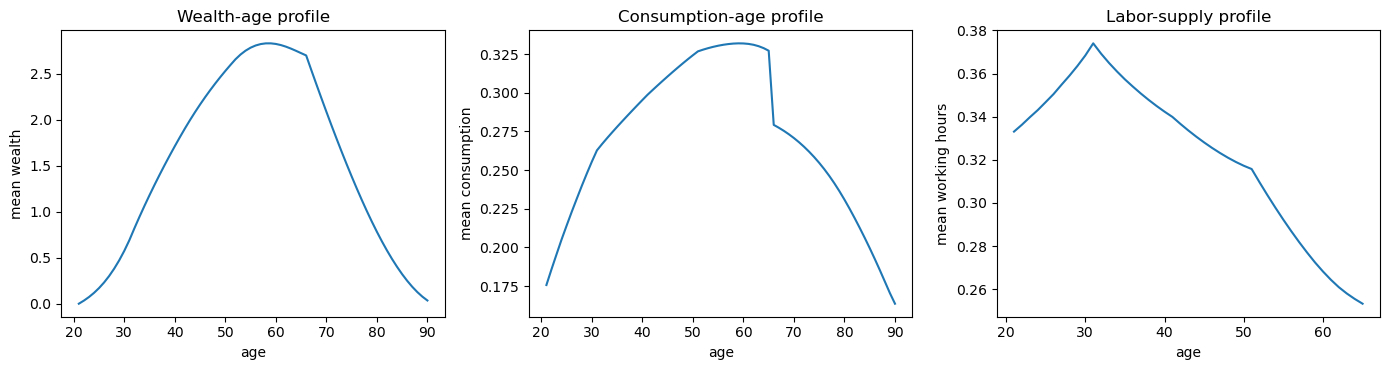

Total elapsed time: 184.0 s


In [47]:
# One-stop save
np.savez('AK70_results.npz',
         vw=vw, vr=vr,
         awopt=awopt, aropt=aropt,
         cwopt=cwopt, cropt=cropt, lopt=lopt,
         gkw=gkw, gkr=gkr,
         cgen=cgen, lgen=lgen, kgen=kgen,
         earn=earn, gearn=gearn,
         gwealth=gwealth, ag=ag,
         gini_wealth=gini_wealth, gini_earnings=gini_earnings,
         gini_income=gini_income)

# Life-cycle profiles
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].plot(range(21, 91), kgen / mass)
axes[0].set_xlabel('age'); axes[0].set_ylabel('mean wealth'); axes[0].set_title('Wealth-age profile')

axes[1].plot(range(21, 91), cgen)
axes[1].set_xlabel('age'); axes[1].set_ylabel('mean consumption'); axes[1].set_title('Consumption-age profile')

axes[2].plot(range(21, 66), lgen)
axes[2].set_xlabel('age'); axes[2].set_ylabel('mean working hours'); axes[2].set_title('Labor-supply profile')

plt.tight_layout(); plt.show()


print(f"Total elapsed time: {time.time() - t0:.1f} s")

## Step 8 Closing the loop (exercise)

To get a true equilibrium rather than a single iteration, replace this notebook's linear
sequence with the following structure:

```python
diff = 1.0
it   = 0
while diff > tol and it < nq:
    # ---- Step 3 ----
    w   = wage(kbar, nbar);  r  = interest(kbar, nbar)
    rb  = (1-tauk)*(r-delta)
    pen = replacement_ratio * w * mean_labor

    # ---- Step 4: VFI ----
    # ... retiree backward induction ...
    # ... worker  backward induction ...

    # ---- Step 5: forward simulation ----
    # ... gkw, gkr update ...

    # ---- Step 6: aggregate ----
    # ... omeganew, nnew, bigc, bequests ...

    # ---- Step 7: damped update + check convergence ----
    knew_, nnew_, taup_, trbar_ = ...
    diff = max(abs(knew_-kbar), abs(nnew_-nbar), abs(taup_-taup),
               abs(trbar_-trbar))
    kbar  = phi*kbar  + (1-phi)*knew_
    nbar  = phi*nbar  + (1-phi)*nnew_
    taup  = phi*taup  + (1-phi)*taup_
    trbar = phi*trbar + (1-phi)*trbar_
    it += 1
```

### Things to try in the lab session

1. **Sensitivity to the replacement rate.** Set `replacement_ratio = 0.45` (Italian level) and
   re-run â€” how do $\tau^p$, mean wealth, and the wealth Gini respond?
2. **Sensitivity to the IES.** Vary `eta` over $\{1.5, 2.0, 3.0\}$ and inspect the consumption-age profile.
3. **Sensitivity to the AR(1) persistence.** Increase `lamb0` to $0.99$ and look at the wealth Gini.
4. **Switch to cubic interpolation.** Set `kind_tol = 'cubic'` at the top and observe Euler residuals
   near the borrowing constraint (slides "Pitfall: cubic interpolation").